### 5.1 **Dataset Loader**

**Purpose:**

Sample dataset entries → return screenshot, task text, DOM snippet, oracle action.

**Input:**

- Dataset directory path
- Number of samples
- File formats: JSON + PNG

In [1]:
import sys
from pathlib import Path

# 1) set this to the path that contains "project root"
PROJECT_ROOT = Path(r"D:\Mtech\Sem 3\Codes\AutoWeb").resolve()
print("Project root:", PROJECT_ROOT)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Project root: D:\Mtech\Sem 3\Codes\AutoWeb


In [2]:
from src.mind2Web_Loader import Mind2WebDataset

import json
import matplotlib.pyplot as plt

dataset = Mind2WebDataset(
    root_dir=r"D:\Environments\Datasets\multimodal-mind2web",
    split="train",
    sample_size= 100,
    shuffle=True,
)

print("Dataset length:", len(dataset))

[MultiModal-Mind2Web] Loaded split 'train' with 7775 rows (raw).
[MultiModal-Mind2Web] Columns: ['action_uid', 'raw_html', 'cleaned_html', 'operation', 'pos_candidates', 'neg_candidates', 'website', 'domain', 'subdomain', 'annotation_id', 'confirmed_task', 'screenshot', 'action_reprs', 'target_action_index', 'target_action_reprs']
Dataset length: 100


Type of Image: <class 'PIL.Image.Image'>
Sample keys: dict_keys(['screenshot', 'instruction', 'raw_html', 'cleaned_html', 'operation', 'candidates', 'oracle_action', 'metadata'])
Operation: {"original_op": "CLICK", "value": "", "op": "CLICK"}
cleaned_html: <html backend_node_id="213">
  <body>
    <div backend_node_id="338">
      <div backend_node_id="340">
        <a backend_node_id="343" aria_label="skip to content">
            <text backend_node_id="344">skip to Content</text>
          </a>
        <a backend_node_id="347" aria_label="skip to Navigation">
            <text backend_node_id="348">skip to Navigation</text>
          </a>
        </div>
      <div backend_node_id="351">
        <header backend_node_id="353" role="banner">
          <div backend_node_id="355">
            <div backend_node_id="357">
              <a backend_node_id="361">
                  <img backend_node_id="204" alt="Amtrak"/>
                </a>
              <div backend_node_id="370">
        

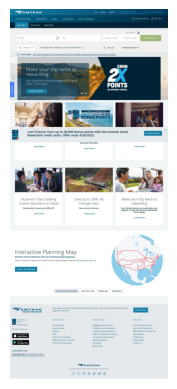

In [3]:
# Let's Load the first sample 

s0 = dataset[0]
print("Type of Image:", type(s0["screenshot"]))
print("Sample keys:", s0.keys())
print("Operation:", s0["operation"])
print("cleaned_html:", s0["cleaned_html"])
print("Metadata:", s0["metadata"])
# parse the candidate JSON string and pretty-print it
candidate_obj = json.loads(s0["candidates"][0])
print("Candidates:", json.dumps(candidate_obj, indent=4))


img = s0["screenshot"]
img.save("test_image.jpg", quality=100)
# plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis("off")
plt.show()

### 5.2 **Preprocessor**

**Purpose:**

- Load screenshot
- Resize, normalize
- Extract DOM elements (if available)
- Optional OCR
- Produce metadata

**Input:** screenshot path, dom snippet

In [4]:
from src.preProcessor import Preprocessor
pp = Preprocessor()

preProcessedData = pp.process(
    cleaned_html=s0["cleaned_html"],
    pos_candidates=s0["candidates"],
)

In [5]:
print("Number of DOM elements:", len(preProcessedData["dom_elements"]))
print("Number of candidates:", len(preProcessedData["candidates"]))
print("\nFirst DOM element:", preProcessedData["dom_elements"][0] if preProcessedData["dom_elements"] else "None")
print("\nFirst candidate:", preProcessedData["candidates"][0] if preProcessedData["candidates"] else "None")

Number of DOM elements: 500
Number of candidates: 1

First DOM element: {'tag': 'div', 'text': 'skip to Content skip to Navigation My Account Loading... Join Sign In My Account Sign Out English Espaol Franais Form open button Search Live Chat Search Form open button Search TRAIN STATUS MY TRIP D', 'id': None, 'class': None, 'attrs': {'backend_node_id': '338'}}

First candidate: {'tag': 'a', 'bbox': (1142.0, 59.0, 1232.0, 108.0), 'is_original_target': False, 'is_top_level_target': True, 'backend_node_id': '3232', 'raw': {'tag': 'a', 'attributes': '{"backend_node_id": "3232", "bounding_box_rect": "1142,59,90,49", "id": "ff_tabbar_mytrip", "role": "button", "class": "is-subnav-link is-subnav-modal site-secondary-nav__li_link ng-star-inserted", "aria_label": "MY TRIP", "data_pw_testid_buckeye_candidate": "1"}', 'is_original_target': False, 'is_top_level_target': True, 'backend_node_id': '3232'}}


### 5.3 **Prompt Engine**

**Purpose:**

Generate multimodal input prompt for Qwen2-VL-2B.

**Input:**

- Task text
- DOM elements (from preprocessor) or raw DOM snippet
- Few-shot examples (optional)
- Image placeholder key

**Output:**

- Prompt text ready for the model
- List of image placeholder keys

In [6]:
s0.keys()

dict_keys(['screenshot', 'instruction', 'raw_html', 'cleaned_html', 'operation', 'candidates', 'oracle_action', 'metadata'])

In [7]:
from src.prompt_engine import PromptEngine

engine = PromptEngine()

prompt_text, image_placeholders = engine.build_prompt(
    task_text=s0['instruction'],
    dom_elements=preProcessedData['dom_elements'],
    image_key="<|vision_start|><|image_pad|><|vision_end|>",
    variant="strict_json",
    include_dom=True
)

In [8]:
print("="*70)
print("GENERATED PROMPT:")
print("="*70)
print(prompt_text)
print("\n" + "="*70)
print(f"Image placeholders in prompt: {image_placeholders}")
print("="*70)

GENERATED PROMPT:
You are a UI action predictor for web automation.

Given a webpage screenshot and a task instruction, predict the next single UI action.

Output EXACTLY ONE JSON object with NO additional text. Use this exact format:

{
  "action_type": "click|type|scroll|noop",
  "target": {"selector": "CSS selector"} OR {"coords": [x, y]} OR {"bbox": [x, y, w, h]} OR null,
  "value": "text to type" OR null,
  "confidence": 0.0 to 1.0
}

Rules:
- action_type: MUST be one of: click, type, scroll, noop
- target: For click/type, provide selector OR coords OR bbox. For scroll/noop, use null
- value: ONLY for type actions. Otherwise null
- confidence: Your confidence score (0.0 = no confidence, 1.0 = certain)

Output ONLY the JSON. No explanations. No markdown. No extra text.

Context (DOM elements):

1. <div> skip to Content skip to Navigation My Account Load
2. <div> skip to Content skip to Navigation
3. <a> skip to Content
4. <a> skip to Navigation
5. <div> My Account Loading... Join S

### 5.4 **Model Interface (Qwen2-VL)**

**Purpose:**

Load multimodal model → perform inference → return raw text.

**Input:**

image tensor, prompt text

**Output:**

string (model-generated JSON-like text)

In [9]:
# Load the VLModel with the corrected code
from src.model_interface import VLModel
from PIL import Image

MODEL_FOLDER = r"D:\\Environments\\Models\\Qwen2-VL-2B"

# Try 8-bit if you installed bitsandbytes; otherwise set use_8bit=False
m = VLModel(model_folder=MODEL_FOLDER, use_8bit=False, dtype="fp16")

# Use the already-loaded data and preprocessor from previous cells
# s0 is our sample from the dataset
# prompt_text and image_placeholders are from the PromptEngine

# Call model (we pass PIL image object directly)
res = m.infer(image_or_tensor=s0["screenshot"], prompt_text=prompt_text, max_new_tokens=256, do_sample=False)
print("Latency (s):", res["latency"])
print("\nRaw model output (first 800 chars):")
print(res["raw_text"][:800])

d:\Environments\ml-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[VLModel] bitsandbytes available: True
[VLModel] loading processor from D:\Environments\Models\Qwen2-VL-2B ...


d:\Environments\ml-env\Lib\site-packages\transformers\models\auto\modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


[VLModel] loading model with kwargs: {'torch_dtype': torch.float16, 'device_map': 'auto'}


Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.87s/it]


[VLModel] model loaded. device = cuda, use_8bit=False
[VLModel] generate() model_device=cuda:0, input_ids=torch.Size([1, 5637]), pixel_values=torch.Size([19688, 1176])
[VLModel] token preview (first 120 tokens): ['You', 'Ġare', 'Ġa', 'ĠUI', 'Ġaction', 'Ġpredictor', 'Ġfor', 'Ġweb', 'Ġautomation', '.ĊĊ', 'Given', 'Ġa', 'Ġwebpage', 'Ġscreenshot', 'Ġand', 'Ġa', 'Ġtask', 'Ġinstruction', ',', 'Ġpredict', 'Ġthe', 'Ġnext', 'Ġsingle', 'ĠUI', 'Ġaction', '.ĊĊ', 'Output', 'ĠEX', 'ACT', 'LY', 'ĠONE', 'ĠJSON', 'Ġobject', 'Ġwith', 'ĠNO', 'Ġadditional', 'Ġtext', '.', 'ĠUse', 'Ġthis', 'Ġexact', 'Ġformat', ':ĊĊ', '{Ċ', 'Ġ', 'Ġ"', 'action', '_type', '":', 'Ġ"', 'click', '|', 'type', '|', 'scroll', '|', 'noop', '",Ċ', 'Ġ', 'Ġ"', 'target', '":', 'Ġ{"', 'selector', '":', 'Ġ"', 'CSS', 'Ġselector', '"}', 'ĠOR', 'Ġ{"', 'coords', '":', 'Ġ[', 'x', ',', 'Ġy', ']}', 'ĠOR', 'Ġ{"', 'bbox', '":', 'Ġ[', 'x', ',', 'Ġy', ',', 'Ġw', ',', 'Ġh', ']}', 'ĠOR', 'Ġnull', ',Ċ', 'Ġ', 'Ġ"', 'value', '":', 'Ġ"', 'text', 'Ġto', 'Ġt

In [10]:
import json

print(json.dumps(res, indent=4, default=str))

{
    "raw_text": "You are a UI action predictor for web automation.\n\nGiven a webpage screenshot and a task instruction, predict the next single UI action.\n\nOutput EXACTLY ONE JSON object with NO additional text. Use this exact format:\n\n{\n  \"action_type\": \"click|type|scroll|noop\",\n  \"target\": {\"selector\": \"CSS selector\"} OR {\"coords\": [x, y]} OR {\"bbox\": [x, y, w, h]} OR null,\n  \"value\": \"text to type\" OR null,\n  \"confidence\": 0.0 to 1.0\n}\n\nRules:\n- action_type: MUST be one of: click, type, scroll, noop\n- target: For click/type, provide selector OR coords OR bbox. For scroll/noop, use null\n- value: ONLY for type actions. Otherwise null\n- confidence: Your confidence score (0.0 = no confidence, 1.0 = certain)\n\nOutput ONLY the JSON. No explanations. No markdown. No extra text.\n\nContext (DOM elements):\n\n1. <div> skip to Content skip to Navigation My Account Load\n2. <div> skip to Content skip to Navigation\n3. <a> skip to Content\n4. <a> skip to N

In [11]:
print(res["raw_text"])

You are a UI action predictor for web automation.

Given a webpage screenshot and a task instruction, predict the next single UI action.

Output EXACTLY ONE JSON object with NO additional text. Use this exact format:

{
  "action_type": "click|type|scroll|noop",
  "target": {"selector": "CSS selector"} OR {"coords": [x, y]} OR {"bbox": [x, y, w, h]} OR null,
  "value": "text to type" OR null,
  "confidence": 0.0 to 1.0
}

Rules:
- action_type: MUST be one of: click, type, scroll, noop
- target: For click/type, provide selector OR coords OR bbox. For scroll/noop, use null
- value: ONLY for type actions. Otherwise null
- confidence: Your confidence score (0.0 = no confidence, 1.0 = certain)

Output ONLY the JSON. No explanations. No markdown. No extra text.

Context (DOM elements):

1. <div> skip to Content skip to Navigation My Account Load
2. <div> skip to Content skip to Navigation
3. <a> skip to Content
4. <a> skip to Navigation
5. <div> My Account Loading... Join Sign In My Account 

In [12]:
print("given Task:", s0['instruction'])
print("Actual Operation:", s0["operation"])


given Task: Find trip for 123456 last name Smith.
Actual Operation: {"original_op": "CLICK", "value": "", "op": "CLICK"}


In [13]:
import re
import json

output_pattern = r'Output:\s*(\{.*?\})'
output_match = re.search(output_pattern, res["raw_text"], re.DOTALL | re.IGNORECASE)

### 5.5 **Output Parser (Extract JSON from Model Response)**

**Purpose:**

Extract structured JSON output from the model's text response using regex.

**Methods:**
1. Direct JSON parsing (if model outputs clean JSON)
2. Regex extraction (find JSON object within text)
3. Fallback parsing (handle partial/malformed responses)

In [14]:

def extract_json_from_text(text: str) -> dict:
    """
    Extract JSON object from model's text response using multiple strategies.
    
    Args:
        text: Raw text from model output
        
    Returns:
        Parsed JSON dict or None if extraction failed
    """
    
    # Strategy 1: Look for "Output:" line followed by JSON (most specific for our case)
    output_pattern = r'Output:\s*(\{.*?\})'
    output_match = re.search(output_pattern, text, re.DOTALL | re.IGNORECASE)
    if output_match:
        try:
            json_str = output_match.group(1).strip()
            return json.loads(json_str)
        except json.JSONDecodeError:
            pass
    
    # Strategy 2: Try direct JSON parsing (if text is clean JSON)
    try:
        return json.loads(text.strip())
    except json.JSONDecodeError:
        pass
    
    # Strategy 3: Find JSON object using regex (most common case)
    # Pattern matches: {...} with proper nesting
    json_pattern = r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}'
    matches = re.findall(json_pattern, text, re.DOTALL)
    
    for match in matches:
        try:
            parsed = json.loads(match)
            # Validate it has expected keys for our use case
            if isinstance(parsed, dict):
                return parsed
        except json.JSONDecodeError:
            continue
    
    # Strategy 4: More aggressive pattern - find content between first { and last }
    brace_match = re.search(r'\{.*\}', text, re.DOTALL)
    if brace_match:
        try:
            return json.loads(brace_match.group())
        except json.JSONDecodeError:
            pass
    
    # Strategy 5: Extract key-value pairs manually (fallback for malformed JSON)
    result = {}
    
    # Look for action
    action_match = re.search(r'"action"\s*:\s*"([^"]+)"', text)
    if action_match:
        result["action"] = action_match.group(1)
    
    # Look for target
    target_match = re.search(r'"target"\s*:\s*(\{[^}]+\}|null)', text)
    if target_match:
        try:
            result["target"] = json.loads(target_match.group(1))
        except:
            result["target"] = None
    
    # Look for value
    value_match = re.search(r'"value"\s*:\s*"([^"]*)"', text)
    if value_match:
        result["value"] = value_match.group(1)
    elif re.search(r'"value"\s*:\s*null', text):
        result["value"] = None
    
    # Look for confidence
    conf_match = re.search(r'"confidence"\s*:\s*([\d.]+)', text)
    if conf_match:
        result["confidence"] = float(conf_match.group(1))
    
    return result if result else None


# Test with the model output
print("Raw model output:")
print(res["raw_text"])
print("\n" + "="*70 + "\n")

parsed_output = extract_json_from_text(res["raw_text"])

if parsed_output:
    print("✓ Successfully extracted JSON:")
    print(json.dumps(parsed_output, indent=2))
else:
    print("✗ Failed to extract JSON from output")

Raw model output:
You are a UI action predictor for web automation.

Given a webpage screenshot and a task instruction, predict the next single UI action.

Output EXACTLY ONE JSON object with NO additional text. Use this exact format:

{
  "action_type": "click|type|scroll|noop",
  "target": {"selector": "CSS selector"} OR {"coords": [x, y]} OR {"bbox": [x, y, w, h]} OR null,
  "value": "text to type" OR null,
  "confidence": 0.0 to 1.0
}

Rules:
- action_type: MUST be one of: click, type, scroll, noop
- target: For click/type, provide selector OR coords OR bbox. For scroll/noop, use null
- value: ONLY for type actions. Otherwise null
- confidence: Your confidence score (0.0 = no confidence, 1.0 = certain)

Output ONLY the JSON. No explanations. No markdown. No extra text.

Context (DOM elements):

1. <div> skip to Content skip to Navigation My Account Load
2. <div> skip to Content skip to Navigation
3. <a> skip to Content
4. <a> skip to Navigation
5. <div> My Account Loading... Join S